## Introduction
Remember to read the manual pages on the matlab commands before using them. The
project can also be solved using Python. It is then up to the student to figure out the link
between matlab and Python code. This project is described for matlab users.

## 1 Random variables
### 1.1 Random variables - uniform PDF
Generate a long vector x of samples of a uniform random variable using the matlab function
rand. Use several thousand samples.
Estimate the probability density function (PDF), the first order moment (or the mean
value) mx = E{x}, and the second order central moment (or the variance) σ2x
= E{(x −
mx)2}. Use the matlab functions histogram or histcounts, mean and std. Try to do
the proper normalization yourself for the estimation of the PDF. That is, do not use the
histogram-function with ’Normalization’ set to ’pdf’ or ’probability’.
Make sure that the estimated PDF obeys the properties of a PDF (see lecture notes 1). Plot
the estimated PDF. Plot the theoretical PDF on top in the same figure in a different colour.
Use the matlab command hold on to put several plots in the same figure.
Derive the theoretical values for the mean mx and the variance σ2x
. That is, solve the
integral formula for expectation of the random variable and the second order central
moment. Assume that the uniform PDF is 1 in the interval [0,1]. Equations must be
shown in the presentation. No plot or code needed here.
Repeat the numerical experiment several times and observe. Plot the estimated mean
value and variance for all numerical experiments. What happens to to the estimates of
the pdf, mx and σ2x
?

In [2]:
%pip install numpy
%pip install scipy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

plt.style.use('ggplot')

Generate the random sequence

In [4]:
signal_len = 5000
time = range(0, signal_len)
uniform_rand_seq = np.random.rand(signal_len)

Estimate the mean of the signal, E{X}

Mean: 0.49683199099042286
Variance: 0.08387087432214421


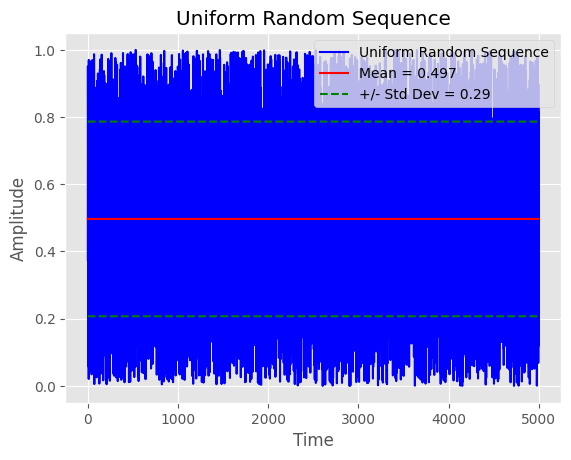

In [20]:
mean = np.mean(uniform_rand_seq)
variance = np.var(uniform_rand_seq)

print("Mean: " + str(mean))
print("Variance: " + str(variance))

plt.plot(time, uniform_rand_seq, 'b')
plt.plot(time, np.zeros(signal_len)+mean, 'r')
plt.plot(time, np.zeros(signal_len)+mean+np.sqrt(variance), 'g--')
plt.plot(time, np.zeros(signal_len)+mean-np.sqrt(variance), 'g--')
plt.title('Uniform Random Sequence')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend(['Uniform Random Sequence', 'Mean = ' + str(round(mean, 3)), '+/- Std Dev = ' + str(round(np.sqrt(variance), 3))])
plt.show()

Now plotting the histogram of the uniformly distributed values and the theoretical PDF

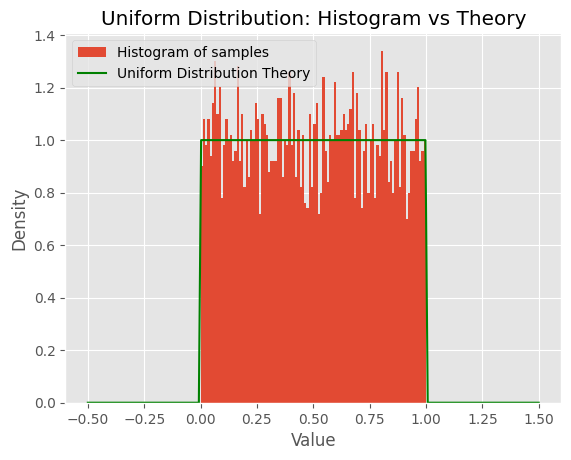

In [23]:
fig, ax0 = plt.subplots(ncols=1, nrows=1) #creating plot axes
(values, bins, _) = ax0.hist(uniform_rand_seq,bins=100,density=True,label="Histogram of samples")

theory_x = np.linspace(-0.5,1.5,200)
padding = np.zeros(50)
theory_y = np.concatenate((padding, np.ones(100), padding))

plt.plot(theory_x, theory_y, 'g')
plt.title('Uniform Distribution: Histogram vs Theory')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend(['Histogram of samples', 'Uniform Distribution Theory'])
plt.show()

## Theoretical mean and variance
For $X \sim \mathcal{U}(0,1)$:

$\mathbb{E}[X] = \int_0^1 x\,dx = \left.\frac{x^2}{2}\right|_0^1 = \frac{1}{2}$

$\mathbb{E}[X^2] = \int_0^1 x^2\,dx = \left.\frac{x^3}{3}\right|_0^1 = \frac{1}{3}$

$\mathrm{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \frac{1}{3} - \left(\frac{1}{2}\right)^2 = \frac{1}{12} \approx 0.0833$

# 1.2 Random variables - Gaussian PDF

In [35]:
normal_dist = np.random.normal(loc=0.0, scale=1.0, size=signal_len)

mean = np.mean(normal_dist)
variance = np.var(normal_dist)

print("Mean: " + str(mean))
print("Variance: " + str(variance))

Mean: -0.000221902765325207
Variance: 1.00132430236398


Plotting

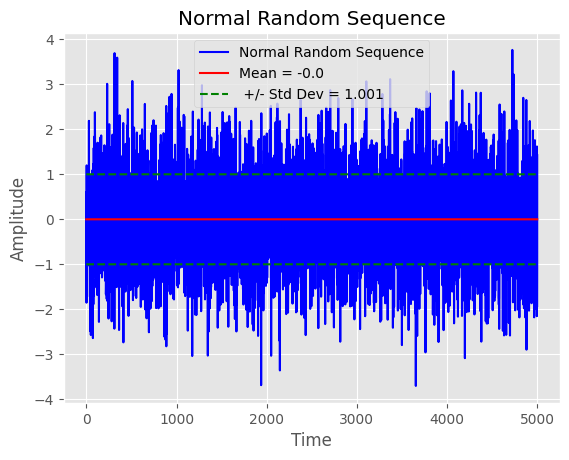

In [36]:
plt.plot(time, normal_dist, 'b')
plt.plot(time, np.zeros(signal_len)+mean, 'r')
plt.plot(time, np.zeros(signal_len)+mean+np.sqrt(variance), 'g--')
plt.plot(time, np.zeros(signal_len)+mean-np.sqrt(variance), 'g--')
plt.title('Normal Random Sequence')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend(['Normal Random Sequence', 'Mean = ' + str(round(mean, 3)), ' +/- Std Dev = ' + str(round(np.sqrt(variance), 3))])
plt.show()

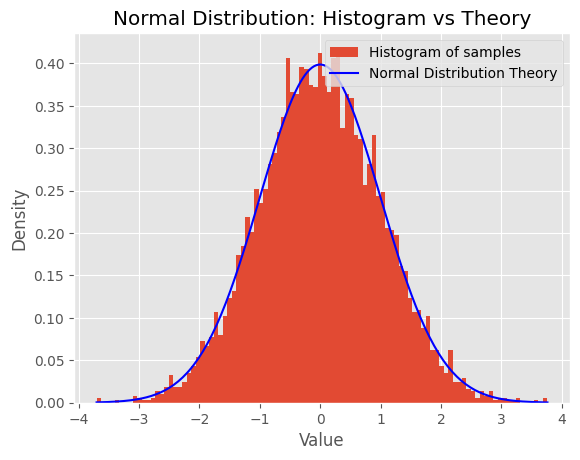

In [37]:
fig, ax0 = plt.subplots(ncols=1, nrows=1) #creating plot axes
(values, bins, _) = ax0.hist(normal_dist,bins=100,density=True,label="Histogram of samples")

x_axis = np.linspace(np.min(normal_dist), np.max(normal_dist), 200)
plt.plot(x_axis, norm.pdf(x_axis, mean, np.sqrt(variance)), 'b')
plt.title('Normal Distribution: Histogram vs Theory')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend(['Histogram of samples', 'Normal Distribution Theory'])
plt.show()

## Calculate the theoretical mean and variance
For $X \sim \mathcal{N}(\mu, \sigma^2)$:

$\mathbb{E}[X] = \int_{-\infty}^{\infty} x\, f_X(x)\,dx = \mu$

$\mathbb{E}[X^2] = \int_{-\infty}^{\infty} x^2\, f_X(x)\,dx = \mu^2 + \sigma^2$

$\mathrm{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2 = \sigma^2$

So, $\mu=0$ and $\sigma=1$, and $\mathbb{E}[X]=0$ and $\mathrm{Var}(X)=1$.

Now show the estimated PDF and the observed PDF

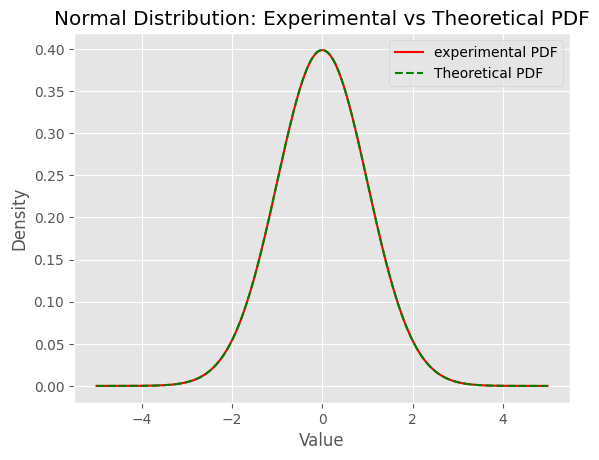

In [39]:
x_axis = np.arange(-5, 5, 0.01)
fig, ax = plt.subplots()
plt.plot(x_axis, norm.pdf(x_axis, mean, np.sqrt(variance)), 'r', label='experimental PDF')
plt.plot(x_axis, norm.pdf(x_axis, 0, 1), 'g--', label='Theoretical PDF')
plt.title('Normal Distribution: Experimental vs Theoretical PDF')
plt.xlabel('Value')
plt.ylabel('Density')
leg = ax.legend()

# 1.3 The Central Limit Theorem
Use rand(12,N) to produce 12 independent uniform random vectors of length N. Average
over each column using the matlab command mean. The result is a single random
vector of length N.
Estimate the PDF from this new random variable using the histogram technique as in
exercise 1.1 and 1.2. Remember normalization. Also estimate the mean and the variance.
Derive the theoretical values for the mean and the variance for the new random variabe
(based on the sum). Equations must be shown in the presentation. A plot or code is
not needed here. Note that the matlab function rand produces a uniformly distributed
random variable with nonzero mean value. Hint: Assume statistical independence to
simplify.
Compare the estimated mean and variance from exercise with the theoretical values derived.
Plot the estimated PDF. Plot the theoretical PDF for a Gaussian random variable
superimposed.

Text(0, 0.5, 'Density')

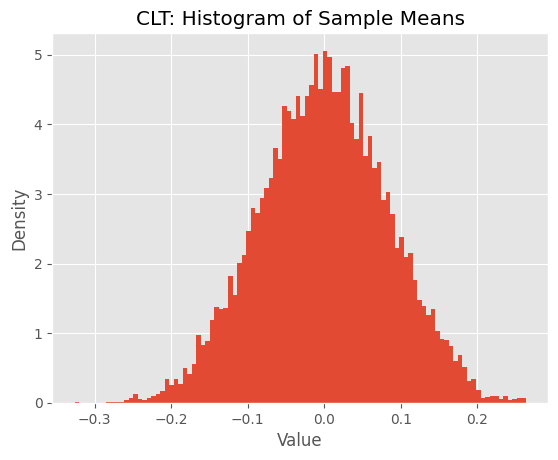

In [52]:
N = 10000
vectors = np.random.rand(12, N)
X = np.mean(vectors, axis=0)
X_norm = (X - np.mean(X))
fig, ax0 = plt.subplots(ncols=1, nrows=1) #creating plot axes
(values, bins, _) = ax0.hist(X_norm,bins=100,density=True,label="Histogram of samples")
plt.title('CLT: Histogram of Sample Means')
plt.xlabel('Value')
plt.ylabel('Density')

calculate variance and mean

In [53]:
mean = np.mean(X_norm)
variance = np.var(X_norm)

print("Mean: " + str(mean))
print("Variance: " + str(variance))

Mean: -2.7133850721838827e-17
Variance: 0.006925490372337606


# Part 2 Stationarity and Ergodicity
Inthis exercisewe consider three randomprocesses. The followingcodegeneratesM
realizationsandNtimesamplesofeachrandomprocess.

```matlab
function [ v ] = rp1(M,N) %<<------ RANDOM PROCESS #1
a = 0.02;
b =5;
Mc = ones(M,1)*b*sin((1:N)*pi/N);
Ac = a*ones(M,1)*[1:N];
v = ( rand(M,N)-0.5 ).*Mc + Ac;

function [ v ] = rp2(M,N) %<<------ RANDOM PROCESS #2
a = 0.5;
m=3;
v = ( rand(M,N)-0.5 )*m + a;
function [ v ] = rp3(M,N) %<<------ RANDOM PROCESS #3
Ar = rand(M,1)*ones(1,N);
Mr = rand(M,1)*ones(1,N);
v = ( rand(M,N)-0.5 ).*Mr + Ar;
```

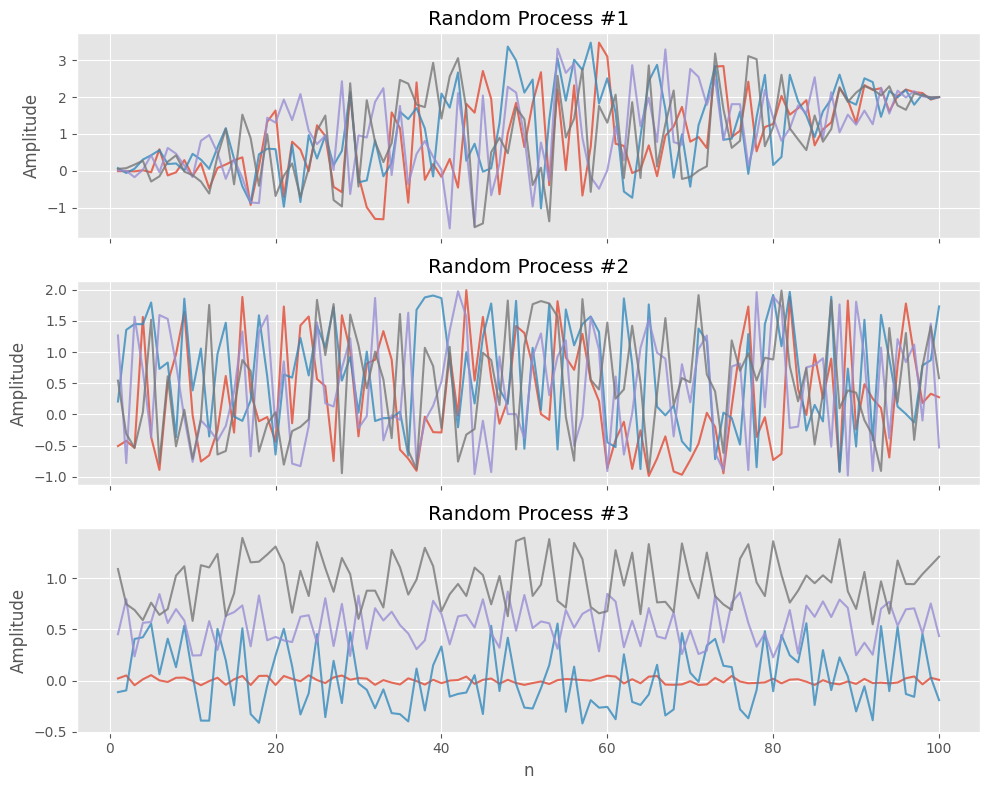

In [61]:
# Parameters
M = 4  # number of realizations
N = 100  # number of time samples

def rp1(M, N):
    a = 0.02
    b = 5
    n = np.arange(1, N + 1)
    Mc = np.ones((M, 1)) * b * np.sin(n * np.pi / N)
    Ac = a * np.ones((M, 1)) * n
    v = (np.random.rand(M, N) - 0.5) * Mc + Ac
    return v

def rp2(M, N):
    a = 0.5
    m = 3
    v = (np.random.rand(M, N) - 0.5) * m + a
    return v

def rp3(M, N):
    Ar = np.random.rand(M, 1) * np.ones((1, N))
    Mr = np.random.rand(M, 1) * np.ones((1, N))
    v = (np.random.rand(M, N) - 0.5) * Mr + Ar
    return v

# Generate realizations
v1 = rp1(M, N)
v2 = rp2(M, N)
v3 = rp3(M, N)

# Plot a few realizations from each process
n = np.arange(1, N + 1)
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

num_plots = min(5, M)
for i in range(num_plots):
    axes[0].plot(n, v1[i, :], alpha=0.8)
axes[0].set_title("Random Process #1")
axes[0].set_ylabel("Amplitude")

for i in range(num_plots):
    axes[1].plot(n, v2[i, :], alpha=0.8)
axes[1].set_title("Random Process #2")
axes[1].set_ylabel("Amplitude")

for i in range(num_plots):
    axes[2].plot(n, v3[i, :], alpha=0.8)
axes[2].set_title("Random Process #3")
axes[2].set_xlabel("n")
axes[2].set_ylabel("Amplitude")

plt.tight_layout()

## 2.1 Stationary or Ergodic
By inspection: 
- Process 1 is non-stationary because the statstical properties of the signal such as mean are time-variant. It is non-ergodic because it is non-stationary.
- Process 2 is stationary and ergodic.
- Process 3 is stationary and non-ergodic.

## 2.2 Ensemble Averages


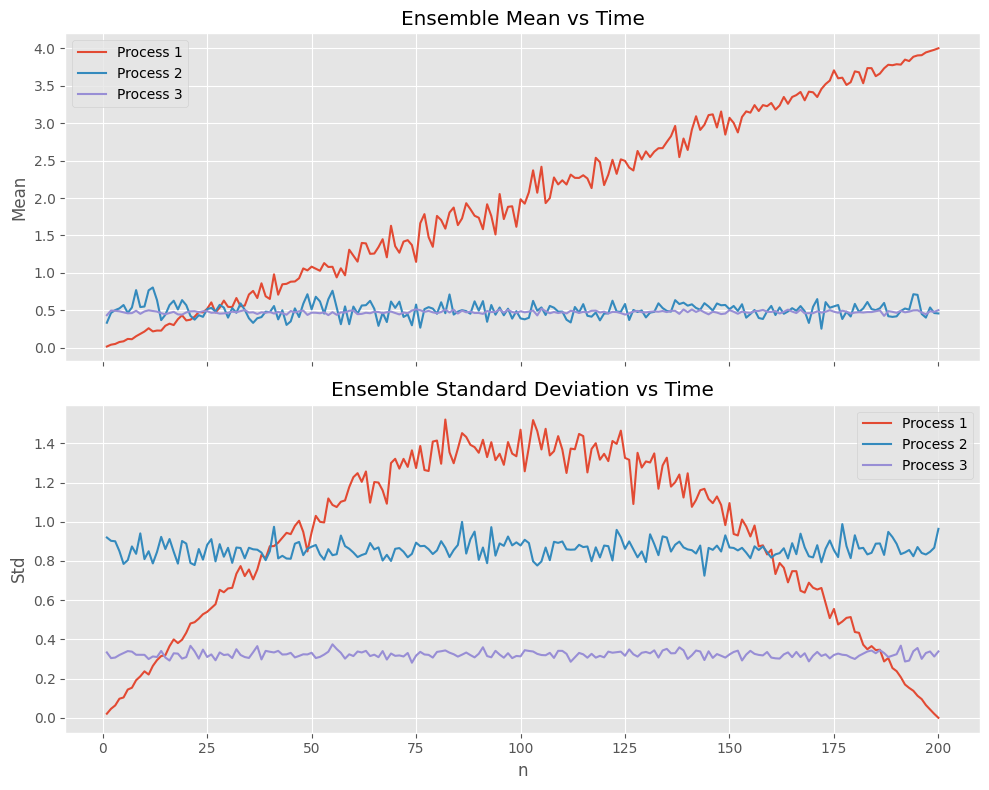

In [62]:
# Ensemble mean and standard deviation for each process
M = 80
N = 200

v1 = rp1(M, N)
v2 = rp2(M, N)
v3 = rp3(M, N)

n = np.arange(1, N + 1)

mean_v1 = np.mean(v1, axis=0)
mean_v2 = np.mean(v2, axis=0)
mean_v3 = np.mean(v3, axis=0)

std_v1 = np.std(v1, axis=0)
std_v2 = np.std(v2, axis=0)
std_v3 = np.std(v3, axis=0)

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(n, mean_v1, label="Process 1")
axes[0].plot(n, mean_v2, label="Process 2")
axes[0].plot(n, mean_v3, label="Process 3")
axes[0].set_title("Ensemble Mean vs Time")
axes[0].set_ylabel("Mean")
axes[0].legend()

axes[1].plot(n, std_v1, label="Process 1")
axes[1].plot(n, std_v2, label="Process 2")
axes[1].plot(n, std_v3, label="Process 3")
axes[1].set_title("Ensemble Standard Deviation vs Time")
axes[1].set_xlabel("n")
axes[1].set_ylabel("Std")
axes[1].legend()

plt.tight_layout()

## 2.3 Time Averages

Time averages (Process 1): [10.05124019 10.00410599 10.00835868  9.98789808]
Time averages (Process 2): [0.51387754 0.5082959  0.48634397 0.50238222]
Time averages (Process 3): [0.76125213 0.39689148 0.5524939  0.90761302]


Time variances (Process 1): [34.23454605 34.80057994 34.17614046 34.47483331]
Time variances (Process 2): [0.74284252 0.74547335 0.70376027 0.75683105]
Time variances (Process 3): [0.04908665 0.00843634 0.03084987 0.01591295]


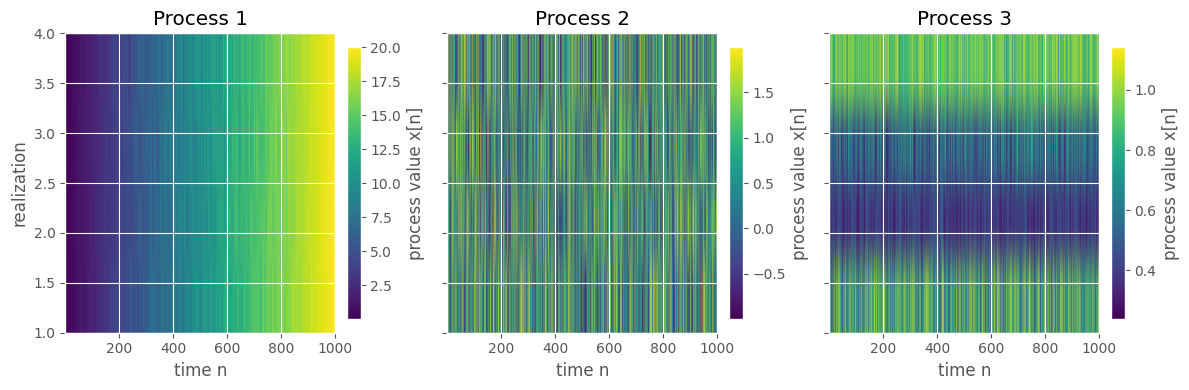

In [ ]:
# Time averages
M = 4
N = 1000

v1 = rp1(M, N)
v2 = rp2(M, N)
v3 = rp3(M, N)

# Time averages per realization (mean over time samples)
mean_time_v1 = np.mean(v1, axis=1)
mean_time_v2 = np.mean(v2, axis=1)
mean_time_v3 = np.mean(v3, axis=1)

print("Time averages (Process 1):", mean_time_v1)
print("Time averages (Process 2):", mean_time_v2)
print("Time averages (Process 3):", mean_time_v3)

# Time variances per realization (variance over time samples)
var_time_v1 = np.var(v1, axis=1)
var_time_v2 = np.var(v2, axis=1)
var_time_v3 = np.var(v3, axis=1)
print("\n\nTime variances (Process 1):", var_time_v1)
print("Time variances (Process 2):", var_time_v2)
print("Time variances (Process 3):", var_time_v3)

# Plots (time on x-axis, realization on y-axis)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

im0 = axes[0].imshow(v1, aspect="auto", origin="lower", extent=[1, N, 1, M])
axes[0].set_title("Process 1")
axes[0].set_xlabel("time n")
axes[0].set_ylabel("realization")
cb0 = fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(v2, aspect="auto", origin="lower", extent=[1, N, 1, M])
axes[1].set_title("Process 2")
axes[1].set_xlabel("time n")
cb1 = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(v3, aspect="auto", origin="lower", extent=[1, N, 1, M])
axes[2].set_title("Process 3")
axes[2].set_xlabel("time n")
cb2 = fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)
cb2.set_label("process value x[n]")

plt.tight_layout()

Ergodicity:
- Process 1 is non-stationary, so it is non-ergodic.
- Process 2 is stationary with time averages converging to the ensemble mean/variance, so it is ergodic.
- Process 3 is stationary but has realization-dependent mean, so time averages depend on the realization; it is non-ergodic.

If the image shows statistics changing with time in the horizontal direction, the process is non-stationary. If different realizations have clearly different offsets or spreads, that indicates non-ergodicity in mean/variance.